# CKA Analysis: Pretrained Embeddings vs ADMET Labels

Compares graph-level embeddings from **PairMixer 12M** models pretrained on
different combinations of pre-training datasets against all 22 ADMET benchmark
task labels. Each pre-training case is a column of the heatmap.

**Pre-training cases** (most recent run per case):
- `toymix` — uni-modal molecular baseline (ToyMix only)
- `toymix_dti_esmcv2` — + DTI head w/ ESMCv2 protein embeddings
- `toymix_bbbc047` — + BBBC047 cell-morphology head
- `toymix_lpm24_litopenai` — + LPM-24 head w/ OpenAI text-embedding-3-small
- `toymix_all` — all of the above combined

**Prerequisites**: Run `python scripts/cka_analysis.py` first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams.update({"font.size": 11, "figure.dpi": 120})
sns.set_style("whitegrid")

RESULTS_PATH = "../results/cka_analysis/cka_results.csv"
df = pd.read_csv(RESULTS_PATH)
print(f"Loaded {len(df)} rows, {df['checkpoint'].nunique()} checkpoints, "
      f"{df['task'].nunique()} tasks")
df.head()

Loaded 242 rows, 6 checkpoints, 22 tasks


,checkpoint,modality,task,category,task_type,embedding,linear_cka,kernel_cka,n_molecules
0,data,none,caco2_wang,Absorption,regression,data,0.046825,0.066897,910
1,data,none,hia_hou,Absorption,classification,data,0.104469,0.091239,578
2,data,none,pgp_broccatelli,Absorption,classification,data,0.086564,0.155413,1218
3,data,none,bioavailability_ma,Absorption,classification,data,0.034901,0.035223,640
4,data,none,lipophilicity_astrazeneca,Absorption,regression,data,0.037498,0.034941,4200


In [2]:
from notebook_utils import ADMET_TASK_ORDER as TASK_ORDER, TASK_CATEGORY

# Pre-training cases (heatmap columns). Order goes from minimal -> all-combined.
CKPT_UNI = ["toymix"]
CKPT_MULTI = [
    "toymix_dti_esmcv2",
    "toymix_bbbc047",
    "toymix_lpm24_litopenai",
    "toymix_all",
]
CKPT_ALL = CKPT_UNI + CKPT_MULTI

# Pretty labels for the heatmap x-axis / bar-chart y-axis.
CKPT_LABELS = {
    "toymix":                 "toymix",
    "toymix_dti_esmcv2":      "+ esmcv2",
    "toymix_bbbc047":         "+ bbbc047",
    "toymix_lpm24_litopenai": "+ lit_openai",
    "toymix_all":             "+ all (4data)",
}

CATEGORY_COLORS = {
    "Absorption":   "#4C72B0",
    "Distribution": "#8172B2",
    "Metabolism":   "#DD8452",
    "Excretion":    "#55A868",
    "Toxicity":     "#C44E52",
}

# Separate data baseline from model results
df_data = df[df["checkpoint"] == "data"].copy()
df_model = df[df["checkpoint"] != "data"].copy()

# The CSV mis-tags bbb_martins / ppbr_az / vdss_lombardo as Absorption — use the
# canonical TASK_CATEGORY mapping from notebook_utils so Distribution colors render.
task_to_cat = dict(TASK_CATEGORY)

def color_yticks(ax):
    for label in ax.get_yticklabels():
        cat = task_to_cat.get(label.get_text(), "")
        label.set_color(CATEGORY_COLORS.get(cat, "black"))
        label.set_fontsize(9)


## 1. Full Heatmaps: All Pre-training Cases

CKA values across all 5 pre-training cases (toymix baseline + 4 multi-modal variants)
for each embedding type.

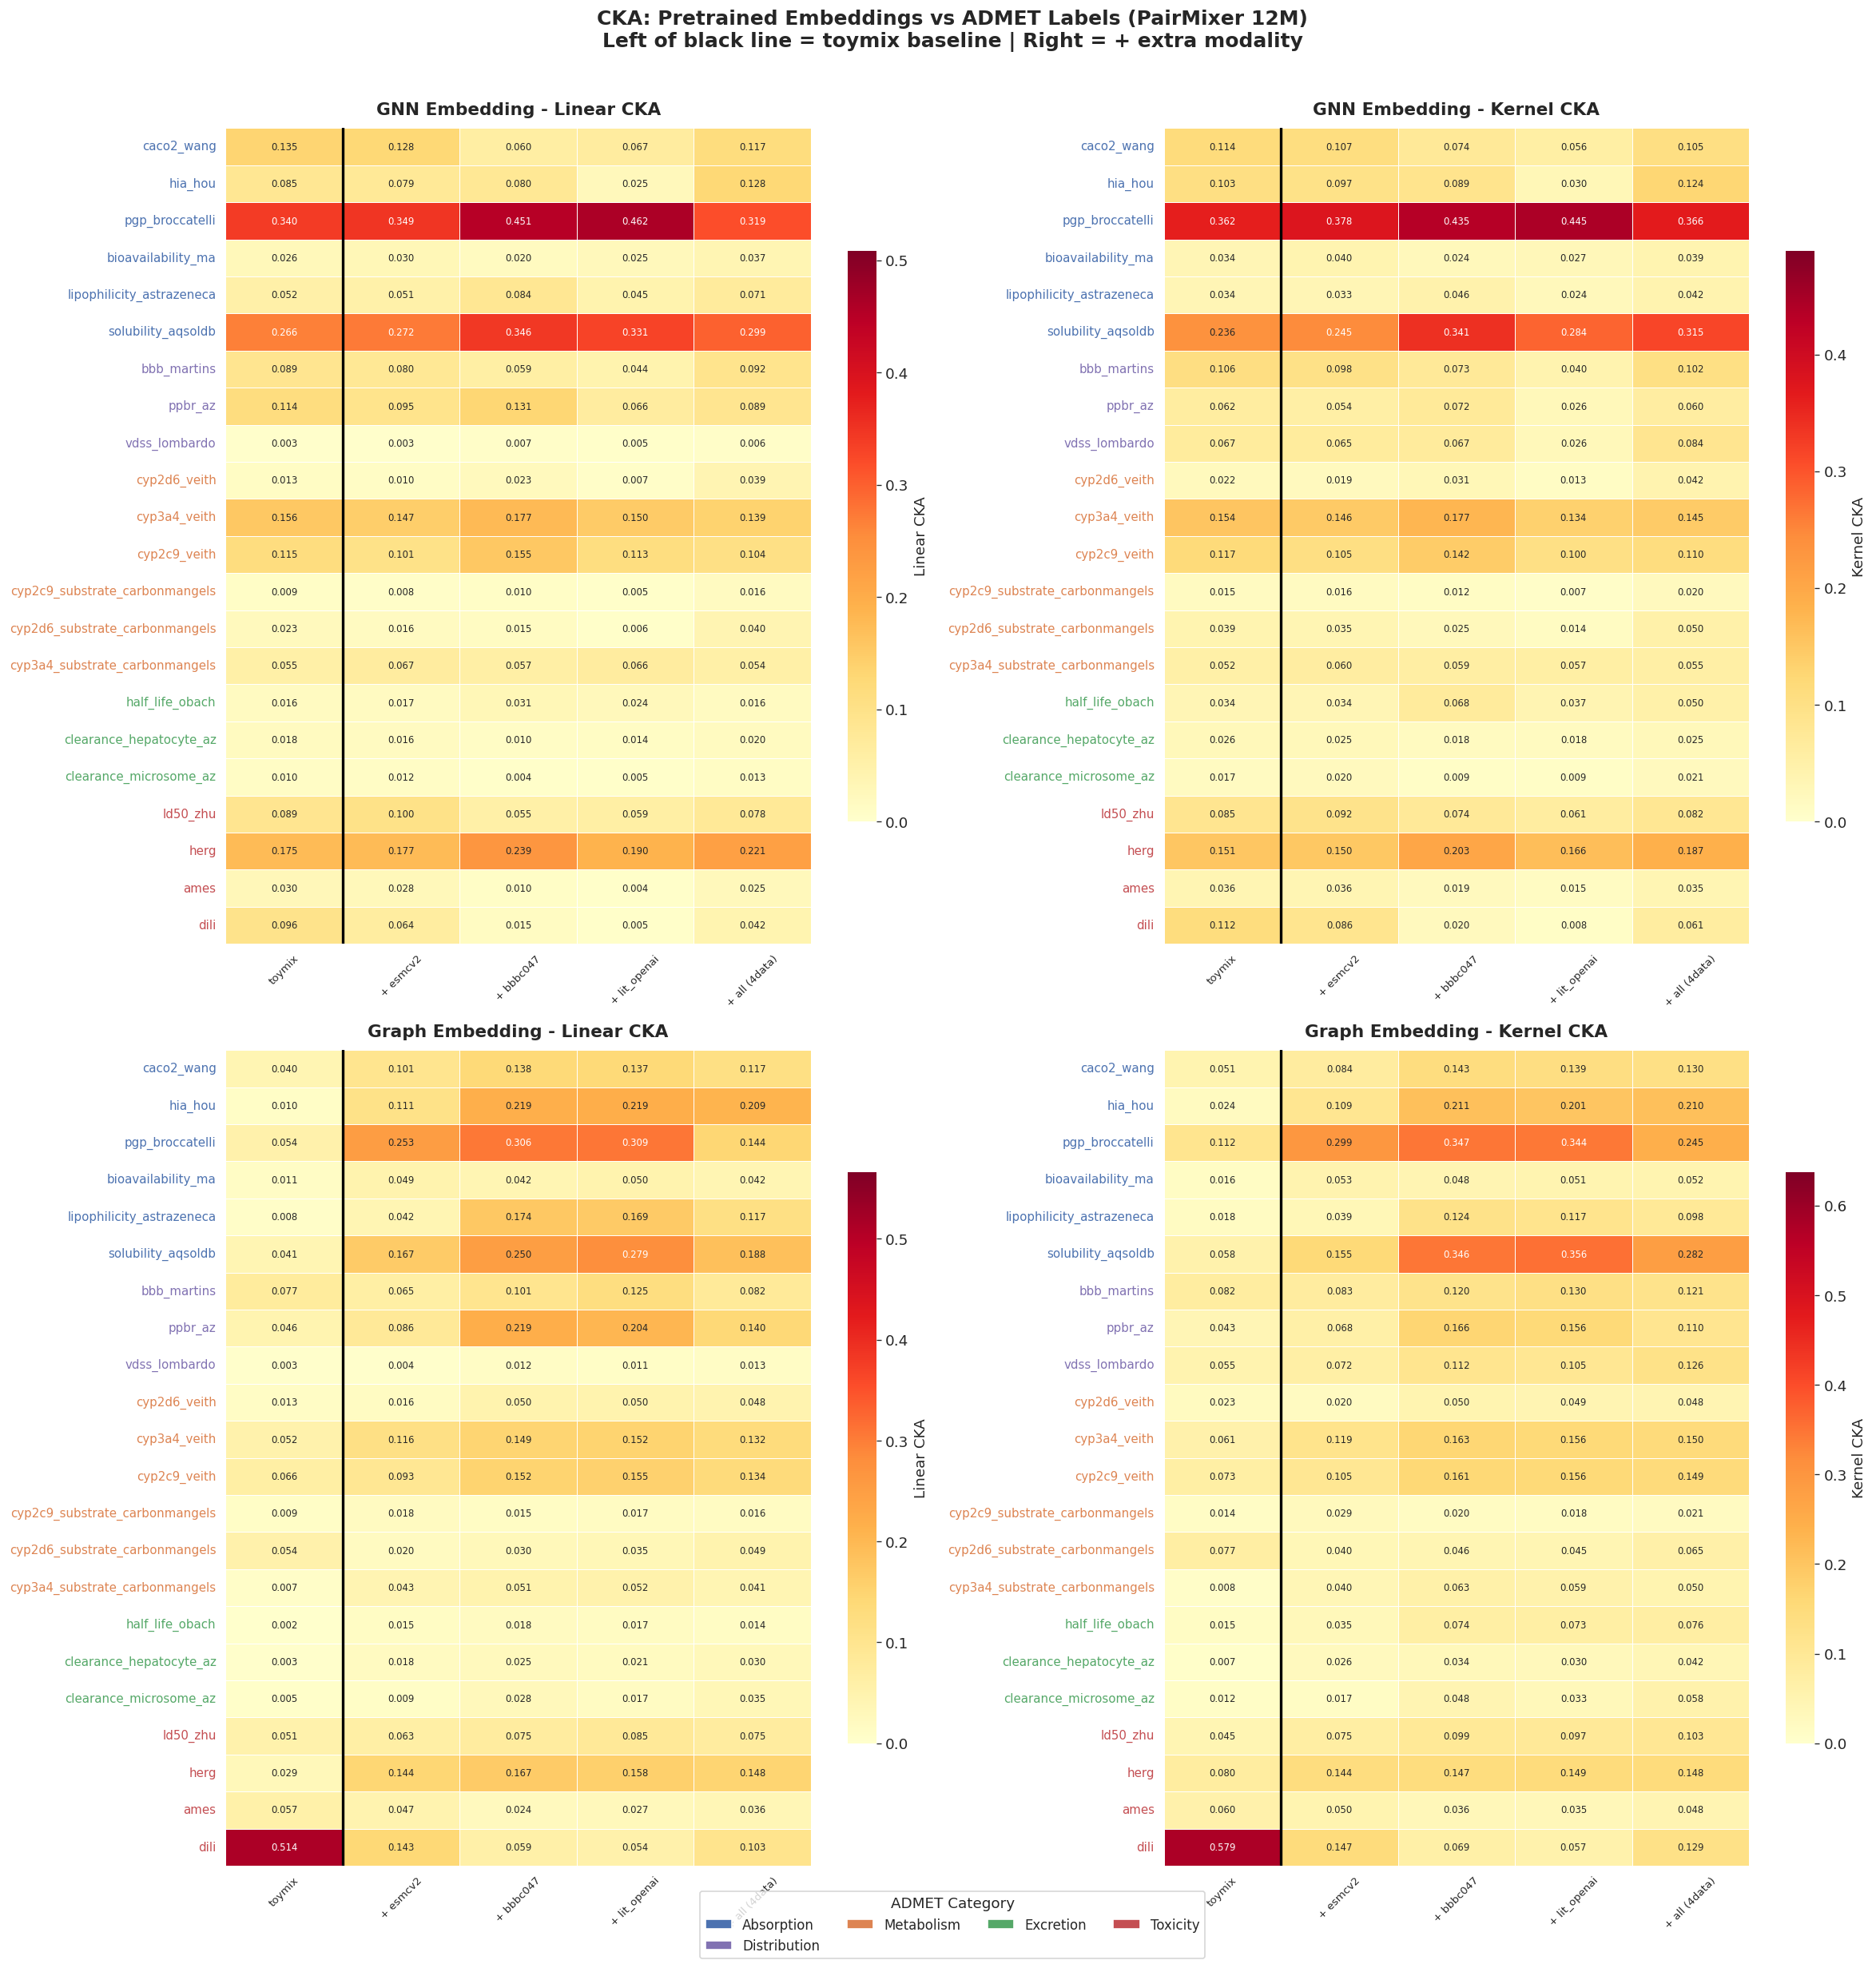

In [3]:
def plot_cka_heatmap(df, emb_type, cka_type, ax, title, ckpt_order=CKPT_ALL):
    sub = df[df["embedding"] == emb_type]
    col = f"{cka_type}_cka"
    pivot = sub.pivot(index="task", columns="checkpoint", values=col)
    pivot = pivot.reindex(index=TASK_ORDER, columns=ckpt_order)
    pivot.columns = [CKPT_LABELS.get(c, c) for c in pivot.columns]
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=".3f", cmap="YlOrRd",
        vmin=0, vmax=max(0.3, pivot.max().max() * 1.1),
        linewidths=0.5, linecolor="white", annot_kws={"fontsize": 7},
        cbar_kws={"label": f"{cka_type.title()} CKA", "shrink": 0.7},
    )
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel(""); ax.set_xlabel("")
    color_yticks(ax)
    ax.tick_params(axis="x", labelsize=8, rotation=45)
    # Divider between uni-modal baseline and multi-modal cases
    if len(ckpt_order) > len(CKPT_UNI):
        ax.axvline(x=len(CKPT_UNI), color="black", linewidth=2)
    return pivot


fig, axes = plt.subplots(2, 2, figsize=(20, 20))
plot_cka_heatmap(df, "gnn", "linear", axes[0, 0], "GNN Embedding - Linear CKA")
plot_cka_heatmap(df, "gnn", "kernel", axes[0, 1], "GNN Embedding - Kernel CKA")
plot_cka_heatmap(df, "graph", "linear", axes[1, 0], "Graph Embedding - Linear CKA")
plot_cka_heatmap(df, "graph", "kernel", axes[1, 1], "Graph Embedding - Kernel CKA")

legend_elements = [matplotlib.patches.Patch(facecolor=c, label=cat)
                   for cat, c in CATEGORY_COLORS.items()]
fig.legend(handles=legend_elements, loc="lower center", ncol=4, fontsize=10,
           title="ADMET Category", bbox_to_anchor=(0.5, -0.01))
fig.suptitle("CKA: Pretrained Embeddings vs ADMET Labels (PairMixer 12M)\n"
             "Left of black line = toymix baseline | Right = + extra modality",
             fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig("../results/cka_analysis/cka_heatmaps_all.png", dpi=150, bbox_inches="tight")
plt.show()

## 1b. Data Baseline: Raw Features vs Model Embeddings

Compares raw atom-feature embeddings (no model, mean-pooled) against all model embeddings.
Shows how much the pretrained models improve alignment with ADMET labels over raw featurization.

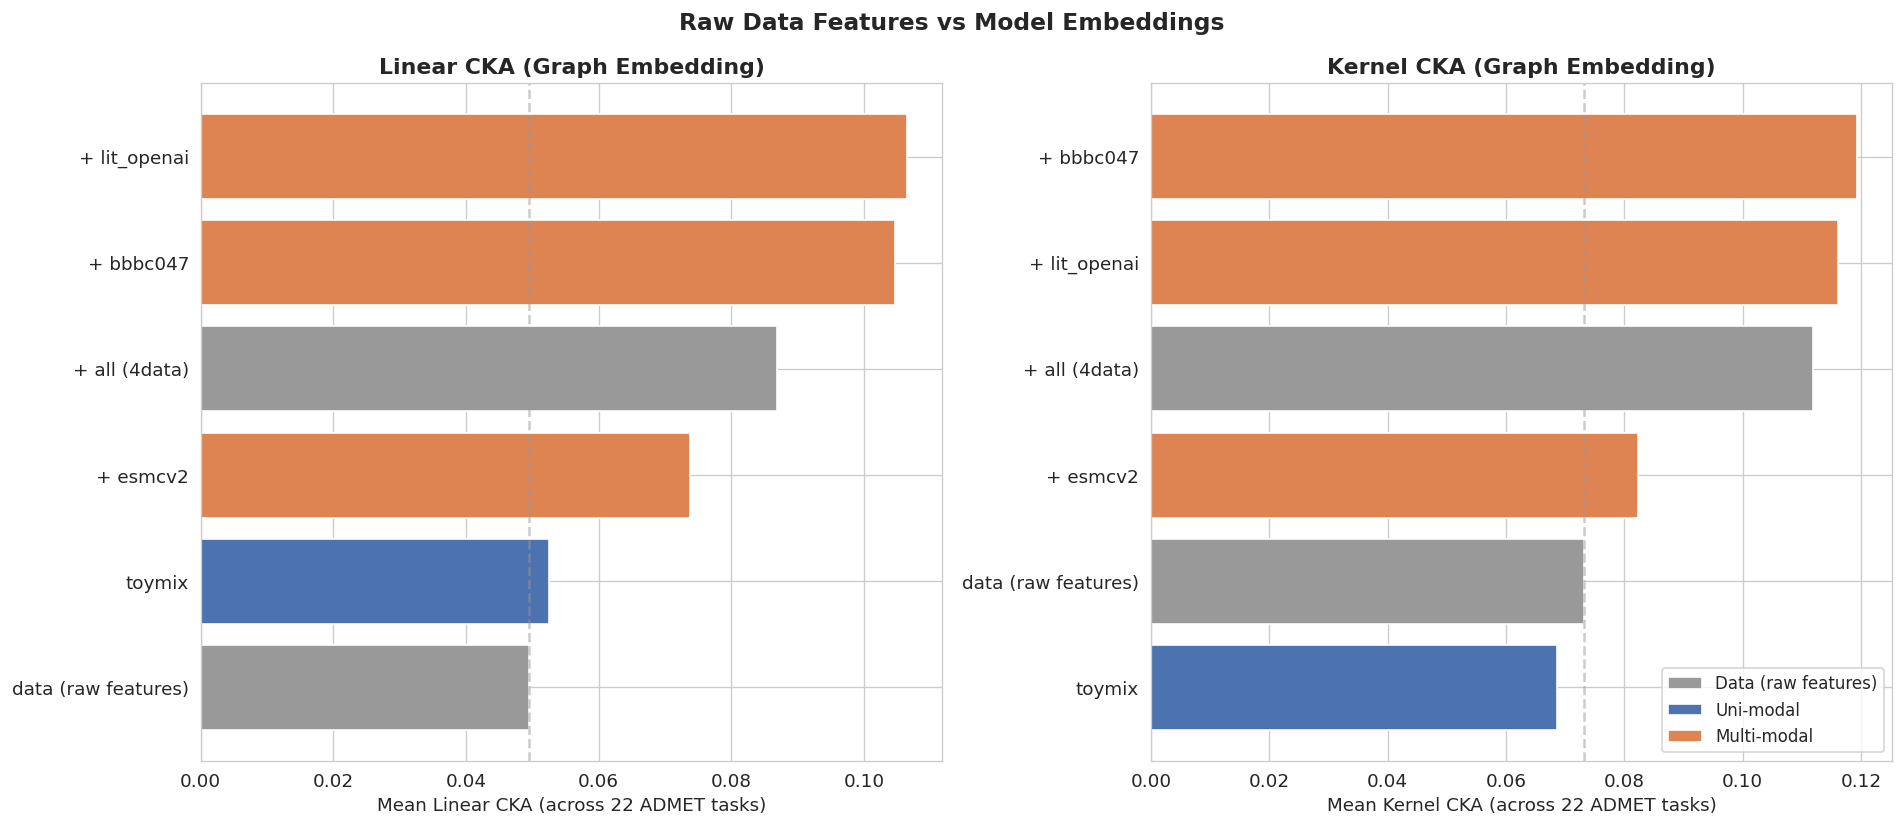

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, cka_type in zip(axes, ["linear", "kernel"]):
    col = f"{cka_type}_cka"

    # Data baseline (single bar per task)
    data_vals = df_data.set_index("task")[col].reindex(TASK_ORDER[::-1])

    # Model means per checkpoint, grouped by embedding type (use graph)
    model_graph = df_model[df_model["embedding"] == "graph"]
    model_means = (
        model_graph.groupby("checkpoint")[col].mean()
        .reindex(CKPT_ALL)
    )

    # Horizontal bar: data baseline + all model checkpoints
    all_means = pd.concat([
        pd.Series({"data (raw features)": data_vals.mean()}),
        model_means,
    ])
    all_means = all_means.sort_values()
    all_means.index = [CKPT_LABELS.get(k, k) for k in all_means.index]

    colors = ["#999999" if "data" in str(k) else
              "#4C72B0" if k in CKPT_UNI else "#DD8452"
              for k in all_means.index]
    ax.barh(all_means.index, all_means.values, color=colors, edgecolor="white")
    ax.set_xlabel(f"Mean {cka_type.title()} CKA (across 22 ADMET tasks)")
    ax.set_title(f"{cka_type.title()} CKA (Graph Embedding)", fontweight="bold")
    ax.axvline(x=data_vals.mean(), color="#999999", linestyle="--", alpha=0.5)

legend_elements = [
    matplotlib.patches.Patch(facecolor="#999999", label="Data (raw features)"),
    matplotlib.patches.Patch(facecolor="#4C72B0", label="Uni-modal"),
    matplotlib.patches.Patch(facecolor="#DD8452", label="Multi-modal"),
]
axes[1].legend(handles=legend_elements, fontsize=10, loc="lower right")

fig.suptitle("Raw Data Features vs Model Embeddings",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig("../results/cka_analysis/cka_data_vs_model.png", dpi=150, bbox_inches="tight")
plt.show()
